In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from matplotlib import cm




#Using formula from Lecture 4-5, slide 7/41
def sigma_model_vec(K, tau, F0, sigma_0, alpha_0, beta, rho_0, a, b):

    
    w = (F0**(1 - beta)) / sigma_0
    
    b_tau_3 = (2 * b * tau)**3
    nu1 = ((6 * alpha_0**2) / b_tau_3) * (((2 * b * tau)**2) / 2 - 2 * b * tau + 1 - np.exp(-2 * b * tau))
    nu2 = ((6 * alpha_0**2) / b_tau_3) * (2 * (np.exp(-2 * b * tau) - 1) + 2 * b * tau * (np.exp(-2 * b * tau) + 1))
    
    ab_tau = (a + b) * tau
    eta1 = ((2 * alpha_0 * rho_0) / (ab_tau**2)) * (np.exp(-ab_tau) - (1 - ab_tau))
    eta2 = ((3 * alpha_0**2 * rho_0**2) / (ab_tau**4)) * (np.exp(-2 * ab_tau) - 8 * np.exp(-ab_tau) + (7 + 2 * ab_tau * (-3 + ab_tau)))

    A1 = (beta - 1) / 2 + eta1 * w / 2
    A2 = (1 - beta)**2 / 12 + (1 - beta - eta1 * w) / 4 + (4 * nu1 + 3 * (eta2 - 3 * eta1**2)) * w**2 / 24
    
    B = (1 / (w**2)) * (((1 - beta)**2) / 24 + (beta * eta1 * w) / 4 + (2 * nu2 - 3 * eta2 )* w**2 / 24)

    log_KF = np.log(K / F0)
    
    model_vol = (1/w) * (1 + A1 * log_KF + A2 * (log_KF**2) + B * tau)
    
    return model_vol


#Compute residuals
def objective_function(params, K, T, F, market_vols):
  
    sigma_0, alpha_0, beta, rho_0, a, b = params
    model_vols = sigma_model_vec(K, T, F, 
                                 sigma_0, alpha_0, beta, rho_0, a, b)
    residuals = model_vols - market_vols
    
    return residuals


Calibrated Parameters:
        sigma_0: 0.294403
        alpha_0: 0.405937
           beta: 1.000000
          rho_0: -0.999971
              a: 0.000000
              b: 0.093586
Final Mean Squared Error (MSE): 5.669375e-05


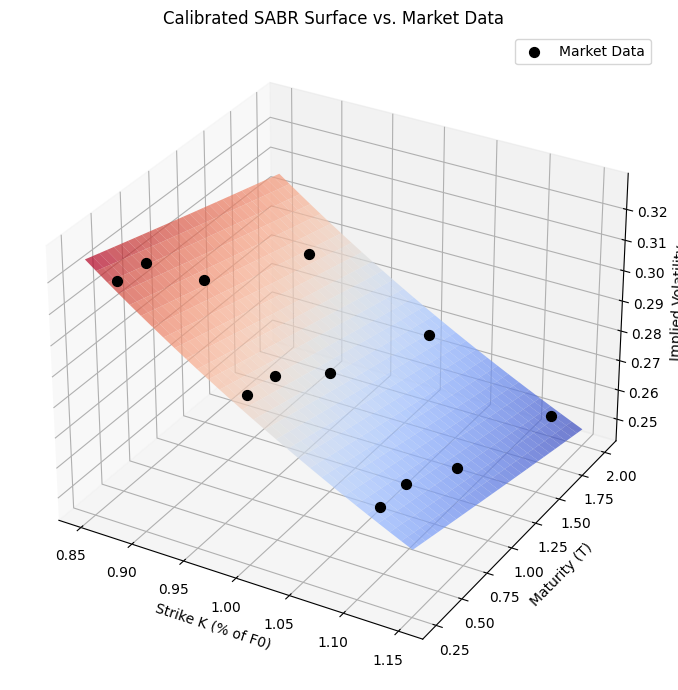

In [ ]:
K_rel = np.array([0.88, 1.0, 1.12]) 
Taus = np.array([0.25, 0.5, 1.0, 2.0]) 
#since k is percentile of price, only need F = 1 for K/F
F0 = 1.0 


Market_Vols_Table = np.array([
    [32.21,  32.07,  30.11,  28.16],  
    [29.79,  29.63,  28.22,  26.54],  
    [27.52,  27.42,  26.34,  24.95]   
])

Market_Vols_Decimal = Market_Vols_Table / 100.0

K_grid, T_grid = np.meshgrid(K_rel, Taus)

K_flat = K_grid.flatten()
T_flat = T_grid.flatten()
Vols_flat = Market_Vols_Decimal.T.flatten() 


p0 = [
    0.2979,  # sigma_0 
    0.5,     # alpha_0 
    0.8,     # beta 
    -0.3,    # rho_0 
    0.1,     # a 
    0.1      # b 
]


# alpha_0 > 0
# 0 < beta < 1
# -1 < rho_0 < 1
# a, b >= 0
bounds = (
    [0.00001, 0.00001, 0., -0.999999, 0.0, 0.0],  
    [2.0,  2.0,  1.,  0.999999, 5.0, 5.0]  
)


#We use least squares to our vector of residuals computed with objective_function
result = least_squares(
    objective_function,
    p0,
    args=(K_flat, T_flat, F0, Vols_flat),
    bounds=bounds,
)


calibrated_params = result.x
param_names = ["sigma_0", "alpha_0", "beta", "rho_0", "a", "b"]
print("Calibrated Parameters:")
for name, val in zip(param_names, calibrated_params):
    print(f"{name:>15}: {val:.6f}")
final_mse =  np.sum(result.fun**2) / len(K_flat)
print(f"Final Mean Squared Error (MSE): {final_mse:.6e}")



sigma_0_cal, alpha_0_cal, beta_cal, rho_0_cal, a_cal, b_cal = calibrated_params
K_plot = np.linspace(0.85, 1.15, 30) #based on values from data
T_plot = np.linspace(0.25, 2.0, 30)  
K_plot_grid, T_plot_grid = np.meshgrid(K_plot, T_plot)

Model_Vols_Surface = sigma_model_vec(
    K_plot_grid, T_plot_grid, F0,
    sigma_0_cal, alpha_0_cal, beta_cal, rho_0_cal, a_cal, b_cal
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# Market data
ax.scatter(K_grid.T, T_grid.T, Market_Vols_Decimal, 
            c='black', s=50, depthshade=False, label='Market Data')
# Calibrated surface
ax.plot_surface(K_plot_grid, T_plot_grid, Model_Vols_Surface, 
                cmap=cm.coolwarm, alpha=0.7, rstride=1, cstride=1)
ax.set_title('Calibrated SABR Surface vs. Market Data')
ax.set_xlabel('Strike K (% of F0)')
ax.set_ylabel('Maturity (T)')
ax.set_zlabel('Implied Volatility')
ax.legend()


plt.tight_layout()
plt.show()


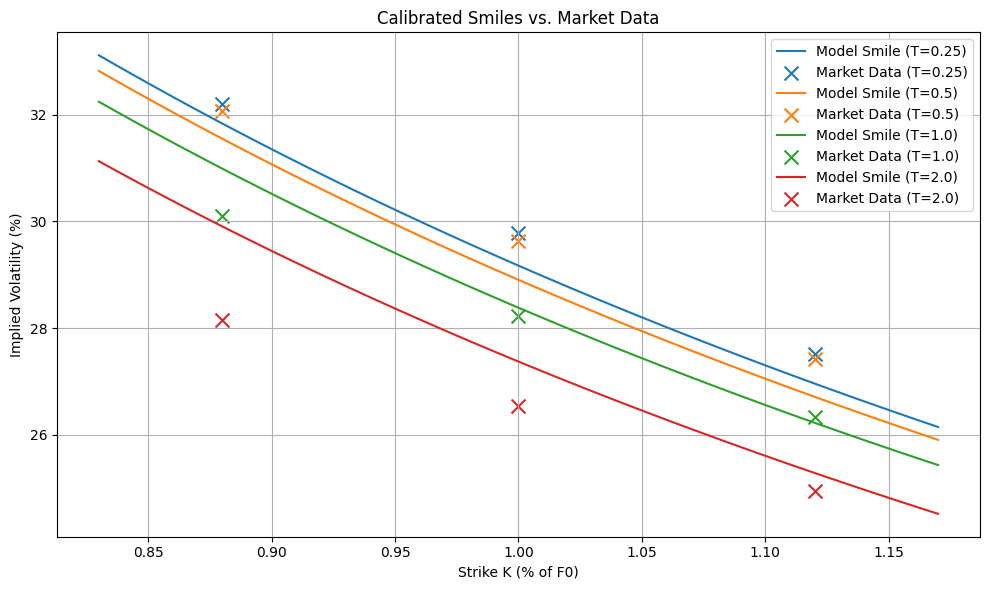

In [3]:
K_plot_smooth = np.linspace(K_rel.min() - 0.05, K_rel.max() + 0.05, 100)
plt.figure(figsize=(10, 6))

for i, T in enumerate(Taus):
    #Vector of T
    T_plot = np.full_like(K_plot_smooth, T)
    #Compute model vols for this T, different K
    model_vols_slice = sigma_model_vec(
        K_plot_smooth, T_plot, F0,
        sigma_0_cal, alpha_0_cal, beta_cal, rho_0_cal, a_cal, b_cal
    )
    
    #Calibrated data
    plt.plot(K_plot_smooth, model_vols_slice * 100, 
                 label=f'Model Smile (T={T})')
    
    market_strikes = K_rel
    market_vols = Market_Vols_Decimal[:, i] 
    plt.scatter(market_strikes, market_vols * 100, 
                s=100, marker='x',
                label=f'Market Data (T={T})') 

plt.title('Calibrated Smiles vs. Market Data')
plt.xlabel('Strike K (% of F0)')
plt.ylabel('Implied Volatility (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()